In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df = pd.read_csv('/content/drive/MyDrive/monkeytype/mt_dataset_pref4feat16.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4675 entries, 0 to 4674
Columns: 168 entries, x1_linspace to x4_f15
dtypes: float64(160), int64(8)
memory usage: 6.0 MB


In [3]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

import os, random
# -----------------------------
# 1) Колонки
# -----------------------------
feat_names = [
    #"linspace",
    "linspace_session_id",
    "linspace_within_session",
    #"brightness",
    #"time_reaction",
    "omission_percent",
    #"symbol_m", "symbol_c", "symbol_s", "symbol_y", "symbol_f", "symbol_j",
    "location_0", "location_1", "location_2", "location_3",
    "participant_J", "participant_F", "participant_Y",
    "correct_target",
    #"correct_symbol_m", "correct_symbol_c", "correct_symbol_s", "correct_symbol_y", "correct_symbol_f", "correct_symbol_j",
]
latent_dim = 16
feat_names_fs = [f"f{i}" for i in range(latent_dim)]
feat_names.extend(feat_names_fs)

F_DIM = len(feat_names)

def idxs(feat_names, names):
    return [feat_names.index(n) for n in names]

base_names = (
    ["location_0", "location_1", "location_2", "location_3"] +
    [f"f{i}" for i in range(16)] + ['correct_target']
)

loc_names = ["location_0", "location_1", "location_2", "location_3"]
img_names = ([f"f{i}" for i in range(latent_dim)] + ['correct_target'])

aux_names = ["omission_percent", "linspace_within_session", "linspace_session_id"
             ]
participant_names = ["participant_J", "participant_F", "participant_Y"]

base_idx = idxs(feat_names, base_names)

loc_idx = idxs(feat_names, loc_names)
img_idx = idxs(feat_names, img_names)
aux_idx = idxs(feat_names, aux_names)
participant_idx = idxs(feat_names, participant_names)


def cols(prefix: str):
    return [f"{prefix}_{f}" for f in feat_names]

x1_cols = cols("x1")
x2_cols = cols("x2")
x3_cols = cols("x3")
x4_cols = cols("x4")

def prepare_arrays(df: pd.DataFrame):
    needed = x1_cols + x2_cols + x3_cols + x4_cols
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    X1 = df[x1_cols].to_numpy(dtype=np.float32)
    X2 = df[x2_cols].to_numpy(dtype=np.float32)
    X3 = df[x3_cols].to_numpy(dtype=np.float32)
    X4 = df[x4_cols].to_numpy(dtype=np.float32)
    return X1, X2, X3, X4

# -----------------------------
# 2) Dataset: возвращает четверку
# -----------------------------
class QuadDataset(Dataset):
    def __init__(self, X1, X2, X3, X4):
        self.X1 = torch.from_numpy(X1).float()
        self.X2 = torch.from_numpy(X2).float()
        self.X3 = torch.from_numpy(X3).float()
        self.X4 = torch.from_numpy(X4).float()

    def __len__(self):
        return self.X1.shape[0]

    def __getitem__(self, idx):
        return self.X1[idx], self.X2[idx], self.X3[idx], self.X4[idx]

def build_mlp(in_dim: int, out_dim: int, hidden=(64, 64), dropout=0.2):
    layers = []
    d = in_dim
    for h in hidden:
        layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
        d = h
    layers += [nn.Linear(d, out_dim)]
    return nn.Sequential(*layers)

class ExpertMoEHard(nn.Module):
    def __init__(self, aux_dim: int, out_dim: int, hidden=(64, 64), dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        self.experts = nn.ModuleList([
            build_mlp(aux_dim, out_dim, hidden=hidden, dropout=dropout),  # J
            build_mlp(aux_dim, out_dim, hidden=hidden, dropout=dropout),  # F
            build_mlp(aux_dim, out_dim, hidden=hidden, dropout=dropout),  # Y
        ])

    def forward(self, aux: torch.Tensor, p_onehot: torch.Tensor) -> torch.Tensor:
        idx = p_onehot.argmax(dim=1)  # (B,)
        w = torch.empty(aux.size(0), self.out_dim, device=aux.device, dtype=aux.dtype)

        for k in (0, 1, 2):
            mask = (idx == k)
            if mask.any():
                w[mask] = self.experts[k](aux[mask])
        return w

class ExpertMoEHardSharedTrunk(nn.Module):
    """
    Shared trunk: aux -> z, then hard-routed heads: z -> w
    """
    def __init__(
        self,
        aux_dim: int,
        out_dim: int,
        *,
        trunk_hidden=(64,),
        head_hidden=(64,),
        dropout=0.2,
    ):
        super().__init__()
        self.out_dim = out_dim

        # общий trunk: aux -> z_dim
        z_dim = trunk_hidden[-1] if len(trunk_hidden) > 0 else aux_dim
        if len(trunk_hidden) > 0:
            self.trunk = build_mlp(aux_dim, z_dim, hidden=trunk_hidden[:-1], dropout=dropout) \
                if len(trunk_hidden) > 1 else nn.Sequential(
                    nn.Linear(aux_dim, z_dim), nn.ReLU(), nn.Dropout(dropout)
                )
        else:
            self.trunk = nn.Identity()
            z_dim = aux_dim

        # 3 головы: z -> out_dim
        self.heads = nn.ModuleList([
            build_mlp(z_dim, out_dim, hidden=head_hidden, dropout=dropout),  # J
            build_mlp(z_dim, out_dim, hidden=head_hidden, dropout=dropout),  # F
            build_mlp(z_dim, out_dim, hidden=head_hidden, dropout=dropout),  # Y
        ])

    def forward(self, aux: torch.Tensor, p_onehot: torch.Tensor) -> torch.Tensor:
        z = self.trunk(aux)                 # (B, z_dim)
        idx = p_onehot.argmax(dim=1)        # (B,)

        w = torch.empty(z.size(0), self.out_dim, device=z.device, dtype=z.dtype)

        for k in (0, 1, 2):
            mask = (idx == k)
            if mask.any():
                w[mask] = self.heads[k](z[mask])
        return w

class ExpertSingle(nn.Module):
    """
    Одна общая сеть aux->w для всех участников.
    p_onehot игнорируем.
    """
    def __init__(self, aux_dim: int, out_dim: int, hidden=(64, 64), dropout=0.2):
        super().__init__()
        self.net = build_mlp(aux_dim, out_dim, hidden=hidden, dropout=dropout)

    def forward(self, aux: torch.Tensor, p_onehot: torch.Tensor) -> torch.Tensor:
        return self.net(aux)

class ExpertSingleWithParticipant(nn.Module):
    """
    Одна сеть, но получает aux и p_onehot как признаки.
    """
    def __init__(self, aux_dim: int, out_dim: int, hidden=(64, 64), dropout=0.2):
        super().__init__()
        self.net = build_mlp(aux_dim + 3, out_dim, hidden=hidden, dropout=dropout)

    def forward(self, aux: torch.Tensor, p_onehot: torch.Tensor) -> torch.Tensor:
        x = torch.cat([aux, p_onehot], dim=1)
        return self.net(x)

class RewardMoECosineSplit(nn.Module):
    def __init__(
        self,
        in_dim_full: int,
        base_idx: list[int],
        aux_idx: list[int],
        participant_idx: list[int],
        *,
        embed_dim: int = 64,
        trunk_hidden=(128, 96),
        expert_hidden=(96, 64),
        dropout=0.2,
        learn_scale=True,
        layernorm_trunk=True,
        layernorm_w=False,
        layernorm_h=False,          # опционально
    ):
        super().__init__()
        self.base_idx = base_idx
        self.aux_idx = aux_idx
        self.participant_idx = participant_idx

        trunk_layers = []
        d = len(base_idx)
        for h in trunk_hidden:
            trunk_layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            if layernorm_trunk:
                trunk_layers += [nn.LayerNorm(h)]
            d = h
        trunk_layers += [nn.Linear(d, embed_dim)]
        if layernorm_trunk:
            trunk_layers += [nn.LayerNorm(embed_dim)]
        self.trunk = nn.Sequential(*trunk_layers)

        #self.moe = ExpertMoEHard(aux_dim=len(aux_idx), out_dim=embed_dim, hidden=expert_hidden, dropout=dropout)

        self.moe = ExpertMoEHardSharedTrunk(
            aux_dim=len(aux_idx),
            out_dim=embed_dim,
            trunk_hidden=(128,),
            head_hidden=(96,64),
            dropout=dropout,
        )

        #self.moe = ExpertSingle(aux_dim=len(aux_idx), out_dim=embed_dim, hidden=expert_hidden, dropout=dropout)
        #self.moe = ExpertSingleWithParticipant(aux_dim=len(aux_idx), out_dim=embed_dim, hidden=expert_hidden, dropout=dropout)

        self.norm_h = nn.LayerNorm(embed_dim) if layernorm_h else None
        self.norm_w = nn.LayerNorm(embed_dim) if layernorm_w else None

        self.scale = nn.Parameter(torch.tensor(1.0)) if learn_scale else None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base = x[:, self.base_idx]
        aux  = x[:, self.aux_idx]
        p    = x[:, self.participant_idx]

        h = self.trunk(base)   # (B,D)
        w = self.moe(aux, p)   # (B,D)

        # LayerNorm -> Normalize (правильный порядок)
        if self.norm_h is not None:
            h = self.norm_h(h)
        if self.norm_w is not None:
            w = self.norm_w(w)

        h = F.normalize(h, dim=1)
        w = F.normalize(w, dim=1)

        # cosine для unit-векторов = dot
        s = (h * w).sum(dim=1)

        if self.scale is not None:
            s = s * self.scale

        return s

    def encode_hw(self, x: torch.Tensor):
        """
        Возвращает нормализованные h, w и score.
        """
        base = x[:, self.base_idx]
        aux  = x[:, self.aux_idx]
        p    = x[:, self.participant_idx]

        h = self.trunk(base)
        w = self.moe(aux, p)

        if self.norm_h is not None:
            h = self.norm_h(h)
        if self.norm_w is not None:
            w = self.norm_w(w)

        h = F.normalize(h, dim=1)
        w = F.normalize(w, dim=1)

        s = (h * w).sum(dim=1)

        if self.scale is not None:
            s = s * self.scale

        return h, w, s

#todo: объединить с build_mlp
def build_mlp_vec(in_dim: int, out_dim: int, hidden=(64, 32), dropout=0.2, layernorm=False):
    layers = []
    d = in_dim
    for h in hidden:
        layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
        if layernorm:
            layers += [nn.LayerNorm(h)]
        d = h
    layers += [nn.Linear(d, out_dim)]
    return nn.Sequential(*layers)

class RewardMoECosineSplitTwoTrunks(nn.Module):
    """
    trunk_loc(location)->h_loc
    trunk_f(f0..f15)->h_f
    h = h_loc + h_f
    moe(aux, participant)->w
    score = cosine(h,w)*scale
    """
    def __init__(
        self,
        in_dim_full: int,
        *,
        loc_idx: list[int],          # индексы x*_location_0..3 (4 штуки)
        img_idx: list[int],            # индексы x*_f0..f15 (16 штук)
        aux_idx: list[int],          # индексы aux признаков
        participant_idx: list[int],  # индексы participant_J,F,Y (3 штуки)
        embed_dim: int = 64,
        trunk_loc_hidden=(32,),
        trunk_img_hidden=(64, 32),
        dropout=0.2,
        learn_scale=True,
        layernorm_loc=False,
        layernorm_img=False,
        layernorm_h=False,            # LN после суммы часто полезен
        layernorm_w=False,
    ):
        super().__init__()
        self.loc_idx = loc_idx
        self.img_idx = img_idx
        self.aux_idx = aux_idx
        self.participant_idx = participant_idx

        self.trunk_loc = build_mlp_vec(
            in_dim=len(loc_idx),
            out_dim=embed_dim,
            hidden=trunk_loc_hidden,
            dropout=dropout,
            layernorm=layernorm_loc,
        )
        self.trunk_img = build_mlp_vec(
            in_dim=len(img_idx),
            out_dim=embed_dim,
            hidden=trunk_img_hidden,
            dropout=dropout,
            layernorm=layernorm_img,
        )

        self.norm_h = nn.LayerNorm(embed_dim) if layernorm_h else None
        self.norm_w = nn.LayerNorm(embed_dim) if layernorm_w else None

        self.moe = ExpertMoEHardSharedTrunk(
            aux_dim=len(aux_idx),
            out_dim=embed_dim,
            trunk_hidden=(128,),
            head_hidden=(96,64),
            dropout=dropout,
        )

        self.scale = nn.Parameter(torch.tensor(1.0)) if learn_scale else None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        loc = x[:, self.loc_idx]     # (B,4)
        img = x[:, self.img_idx]     # (B,16)
        aux = x[:, self.aux_idx]     # (B,aux_dim)
        pj, pf, py = self.participant_idx
        p   = x[:, [pj, pf, py]]     # (B,3)

        h_loc = self.trunk_loc(loc)  # (B,D)
        h_img = self.trunk_img(img)  # (B,D)
        h = h_loc + h_img            # (B,D)

        if self.norm_h is not None:
            h = self.norm_h(h)

        w = self.moe(aux, p)         # (B,D)

        if self.norm_w is not None:
            w = self.norm_w(w)

        h = F.normalize(h, dim=1)
        w = F.normalize(w, dim=1)

        s = (h * w).sum(dim=1)

        if self.scale is not None:
            s = s * self.scale
        return s

    def encode_hw(self, x: torch.Tensor):
        """
        Возвращает нормализованные h, w и score.
        """
        loc = x[:, self.loc_idx]     # (B,4)
        img = x[:, self.img_idx]     # (B,16)
        aux = x[:, self.aux_idx]     # (B,aux_dim)
        pj, pf, py = self.participant_idx
        p   = x[:, [pj, pf, py]]     # (B,3)

        h_loc = self.trunk_loc(loc)  # (B,D)
        h_img = self.trunk_img(img)  # (B,D)
        h = h_loc + h_img            # (B,D)

        if self.norm_h is not None:
            h = self.norm_h(h)

        w = self.moe(aux, p)         # (B,D)

        if self.norm_w is not None:
            w = self.norm_w(w)

        h = F.normalize(h, dim=1)
        w = F.normalize(w, dim=1)

        s = (h * w).sum(dim=1)

        if self.scale is not None:
            s = s * self.scale

        return h, w, s

class ParticipantRotate2HH(nn.Module):
    """
    2×Householder для каждого participant.
    Храним два вектора (U1, U2) размера (3, D).
    Применяем:
        w1 = HH(w, u1)
        w2 = HH(w1, u2)
    """
    def __init__(self, dim: int, eps: float = 1e-8, init_scale: float = 0.005):
        super().__init__()
        self.eps = eps
        self.U1 = nn.Parameter(torch.randn(3, dim) * init_scale)
        self.U2 = nn.Parameter(torch.randn(3, dim) * init_scale)

    def _hh(self, w: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
        # w,u: (B,D)
        uw = (u * w).sum(dim=1, keepdim=True)                      # (B,1)
        uu = (u * u).sum(dim=1, keepdim=True).clamp_min(self.eps)  # (B,1)
        return w - 2.0 * u * (uw / uu)

    def forward(self, w: torch.Tensor, p_onehot: torch.Tensor) -> torch.Tensor:
        idx = p_onehot.argmax(dim=1)  # (B,)
        u1 = self.U1[idx]             # (B,D)
        u2 = self.U2[idx]             # (B,D)
        w = self._hh(w, u1)
        w = self._hh(w, u2)
        return w

class RewardMoECosineSplit2HH(nn.Module):
    """
    Trunk(base)->h, MoE(aux, participant)->w, затем w' = rotate(w, participant),
    score = cosine(h, w').
    """
    def __init__(
        self,
        in_dim_full: int,
        base_idx: list[int],
        aux_idx: list[int],
        participant_idx: list[int],
        *,
        embed_dim: int = 64,
        trunk_hidden=(128, 64),
        expert_hidden=(64, 64),
        dropout=0.2,
        learn_scale=True,
        layernorm_trunk=True,
        layernorm_w=False,
        layernorm_h=False,
        rotate_init_scale=0.005,   # насколько “сильным” будет поворот на старте
    ):
        super().__init__()
        self.base_idx = base_idx
        self.aux_idx = aux_idx
        self.participant_idx = participant_idx

        # trunk: base -> h
        trunk_layers = []
        d = len(base_idx)
        for h in trunk_hidden:
            trunk_layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            if layernorm_trunk:
                trunk_layers += [nn.LayerNorm(h)]
            d = h
        trunk_layers += [nn.Linear(d, embed_dim)]
        if layernorm_trunk:
            trunk_layers += [nn.LayerNorm(embed_dim)]
        self.trunk = nn.Sequential(*trunk_layers)

        # experts: aux -> w
        #self.moe = ExpertMoEHard(aux_dim=len(aux_idx), out_dim=embed_dim, hidden=expert_hidden, dropout=dropout)

        self.moe = ExpertMoEHardSharedTrunk(
            aux_dim=len(aux_idx),
            out_dim=embed_dim,
            trunk_hidden=(128,),
            head_hidden=(96,64),
            dropout=dropout,
        )

        self.norm_h = nn.LayerNorm(embed_dim) if layernorm_h else None
        self.norm_w = nn.LayerNorm(embed_dim) if layernorm_w else None

        # NEW: participant-specific rotation of w
        self.rotate_w = ParticipantRotate2HH(embed_dim, init_scale=rotate_init_scale)

        self.scale = nn.Parameter(torch.tensor(1.0)) if learn_scale else None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base = x[:, self.base_idx]
        aux  = x[:, self.aux_idx]
        p    = x[:, self.participant_idx]  # (B,3)

        h = self.trunk(base)   # (B,D)
        w = self.moe(aux, p)   # (B,D)

        # (опционально) нормировки -> потом normalize
        if self.norm_h is not None:
            h = self.norm_h(h)
        if self.norm_w is not None:
            w = self.norm_w(w)

        # NEW: повернуть/отразить w по участнику
        w = self.rotate_w(w, p)

        # cosine на unit-векторах = dot
        h = F.normalize(h, dim=1)
        w = F.normalize(w, dim=1)
        s = (h * w).sum(dim=1)

        if self.scale is not None:
            s = s * self.scale

        return s

    def encode_hw(self, x: torch.Tensor):
        base = x[:, self.base_idx]
        aux  = x[:, self.aux_idx]
        p    = x[:, self.participant_idx]  # (B,3)

        h = self.trunk(base)   # (B,D)
        w = self.moe(aux, p)   # (B,D)

        # (опционально) нормировки -> потом normalize
        if self.norm_h is not None:
            h = self.norm_h(h)
        if self.norm_w is not None:
            w = self.norm_w(w)

        # NEW: повернуть/отразить w по участнику
        w = self.rotate_w(w, p)

        # cosine на unit-векторах = dot
        h = F.normalize(h, dim=1)
        w = F.normalize(w, dim=1)
        s = (h * w).sum(dim=1)

        if self.scale is not None:
            s = s * self.scale

        return h, w, s


class ParticipantHadamardBiasAlpha(nn.Module):
    """
    w' = w * (1 + alpha * g_p) + alpha * b
    где:
      g_p — (D,) по participant
      b   — (D,) общий или по participant
      alpha ∈ (0,1) общий или по participant (через sigmoid)
    Старт: alpha ~ 0 (почти выключено), g=0, b=0 => w' ≈ w.
    """
    def __init__(
        self,
        dim: int,
        *,
        per_participant_alpha: bool = True,
        per_participant_bias: bool = True,
        init_g: float = 0.0,
        init_b: float = 0.0,
        init_alpha_logit: float = -1.0,  # sigmoid(-4)=0.018 => почти выключено
    ):
        super().__init__()
        self.dim = dim
        self.per_participant_alpha = per_participant_alpha
        self.per_participant_bias = per_participant_bias

        # g_p: (3, D)
        self.G = nn.Parameter(torch.full((3, dim), float(init_g)))

        # bias
        if per_participant_bias:
            self.B = nn.Parameter(torch.full((3, dim), float(init_b)))
        else:
            self.b = nn.Parameter(torch.full((dim,), float(init_b)))

        # alpha logits
        if per_participant_alpha:
            self.alpha_logit = nn.Parameter(torch.full((3,), float(init_alpha_logit)))
        else:
            self.alpha_logit = nn.Parameter(torch.tensor(float(init_alpha_logit)))

    def forward(self, w: torch.Tensor, p_onehot: torch.Tensor) -> torch.Tensor:
        idx = p_onehot.argmax(dim=1)  # (B,)

        g = self.G[idx]               # (B,D)

        if self.per_participant_bias:
            b = self.B[idx]           # (B,D)
        else:
            b = self.b.unsqueeze(0)   # (1,D)

        if self.per_participant_alpha:
            a = torch.sigmoid(self.alpha_logit[idx]).unsqueeze(1)  # (B,1)
        else:
            a = torch.sigmoid(self.alpha_logit).view(1, 1)         # (1,1)

        # w' = w * (1 + a*g) + a*b
        return w * (1.0 + a * g) + a * b

class RewardMoECosineSplitHadamard(nn.Module):
    def __init__(
        self,
        in_dim_full: int,
        base_idx: list[int],
        aux_idx: list[int],
        participant_idx: list[int],
        *,
        embed_dim: int = 64,
        trunk_hidden=(128, 64),
        expert_hidden=(64, 64),
        dropout=0.2,
        learn_scale=True,
        layernorm_trunk=True,
        layernorm_w=False,
        layernorm_h=False,          # опционально
    ):
        super().__init__()
        self.base_idx = base_idx
        self.aux_idx = aux_idx
        self.participant_idx = participant_idx

        trunk_layers = []
        d = len(base_idx)
        for h in trunk_hidden:
            trunk_layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            if layernorm_trunk:
                trunk_layers += [nn.LayerNorm(h)]
            d = h
        trunk_layers += [nn.Linear(d, embed_dim)]
        if layernorm_trunk:
            trunk_layers += [nn.LayerNorm(embed_dim)]
        self.trunk = nn.Sequential(*trunk_layers)

        #self.moe = ExpertMoEHard(aux_dim=len(aux_idx), out_dim=embed_dim, hidden=expert_hidden, dropout=dropout)

        self.moe = ExpertMoEHardSharedTrunk(
            aux_dim=len(aux_idx),
            out_dim=embed_dim,
            trunk_hidden=(128,),
            head_hidden=(96,64),
            dropout=dropout,
        )

        self.norm_h = nn.LayerNorm(embed_dim) if layernorm_h else None
        self.norm_w = nn.LayerNorm(embed_dim) if layernorm_w else None

        self.w_post = ParticipantHadamardBiasAlpha(
            dim=embed_dim,
            per_participant_alpha=True,   # я бы начала с True
            per_participant_bias=True,   # False - bias общий — стабильнее
            init_alpha_logit=-1.0,
            init_g=0.01,
            init_b=0.01,
        )

        self.scale = nn.Parameter(torch.tensor(1.0)) if learn_scale else None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base = x[:, self.base_idx]
        aux  = x[:, self.aux_idx]
        p    = x[:, self.participant_idx]

        h = self.trunk(base)          # (B,D)
        w = self.moe(aux, p)          # (B,D)

        # опциональные нормировки (если используешь)
        if self.norm_h is not None:
            h = self.norm_h(h)
        if self.norm_w is not None:
            w = self.norm_w(w)

        # NEW: participant Hadamard + bias
        w = self.w_post(w, p)

        # cosine через normalize
        h = F.normalize(h, dim=1)
        w = F.normalize(w, dim=1)
        s = (h * w).sum(dim=1)

        if self.scale is not None:
            s = s * self.scale
        return s

    def encode_hw(self, x: torch.Tensor):
        """
        Возвращает нормализованные h, w и score.
        """
        base = x[:, self.base_idx]
        aux  = x[:, self.aux_idx]
        p    = x[:, self.participant_idx]

        h = self.trunk(base)          # (B,D)
        w = self.moe(aux, p)          # (B,D)

        # опциональные нормировки (если используешь)
        if self.norm_h is not None:
            h = self.norm_h(h)
        if self.norm_w is not None:
            w = self.norm_w(w)

        # NEW: participant Hadamard + bias
        w = self.w_post(w, p)

        # cosine через normalize
        h = F.normalize(h, dim=1)
        w = F.normalize(w, dim=1)
        s = (h * w).sum(dim=1)

        if self.scale is not None:
            s = s * self.scale

        return h, w, s

class HardMoEReward3(nn.Module):
    """
    3 независимых reward-сети (J/F/Y), hard routing по participant one-hot.
    Выход: s (B,) — скалярный reward.
    """
    def __init__(self, in_dim: int, participant_idx: tuple[int, int, int], hidden=(128, 64), dropout=0.2):
        super().__init__()
        self.participant_idx = participant_idx

        self.experts = nn.ModuleList([
            build_mlp(in_dim, out_dim = 1, hidden=hidden, dropout=dropout),  # J
            build_mlp(in_dim, out_dim = 1, hidden=hidden, dropout=dropout),  # F
            build_mlp(in_dim, out_dim = 1, hidden=hidden, dropout=dropout),  # Y
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        pj, pf, py = self.participant_idx
        p = x[:, [pj, pf, py]]                 # (B,3)
        idx = p.argmax(dim=1)                  # (B,) values 0/1/2

        B = x.size(0)
        s = torch.empty(B, device=x.device, dtype=x.dtype)  # (B,)

        # hard routing: считаем только подбатчи для каждого эксперта
        for k in (0, 1, 2):
            mask = (idx == k)
            if mask.any():
                s_k = self.experts[k](x[mask]).squeeze(-1)  # (Bk,)
                s[mask] = s_k

        return s

class RewardMLP(nn.Module):
    def __init__(self, in_dim: int, hidden=(64, 32), dropout=0.2):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)] #nn.ReLU()
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)  # (B,)

def loss_listwise_top1(s1, s2, s3, s4, temperature=1.0, l2_scores=9e-4):
    """
    Listwise: -log softmax winner (x1).
    L = -s1 + logsumexp([s1,s2,s3,s4])
    """
    scores0 = torch.stack([s1, s2, s3, s4], dim=1)
    scores = torch.stack([s1, s2, s3, s4], dim=1) / temperature  # (B,4)
    # target winner index = 0
    loss = F.cross_entropy(scores, torch.zeros(scores.size(0), dtype=torch.long, device=scores.device), label_smoothing=0.05)
    # small penalty to keep scores bounded
    loss = loss + l2_scores * (scores0**2).mean()
    return loss

def eval_metrics(model, loader, device, temperature=1.0):
    """
    Оценка на loader для задач top-1 из 4:
      - loss (listwise или pairwise)
      - top1_acc_soft: top-1 с корректной обработкой ties (частичный кредит 1/k)
      - top1_acc_hard: обычный argmax top-1 (может завышать при ties)
      - tie_rate: доля примеров, где максимум не уникален
      - mean_margin: mean(s1 - max(s2,s3,s4))
      - pwin_*: статистики по P(x1 wins) = softmax(scores/T)[0]
    """
    model.eval()

    total_loss = 0.0
    total = 0

    # top-1 метрики
    top1_soft_sum = 0.0
    top1_hard_correct = 0

    # tie diagnostics
    tie_count = 0

    # margin
    margin_sum = 0.0

    # P(win) stats
    p_list = []

    for x1, x2, x3, x4 in loader:
        x1, x2, x3, x4 = x1.to(device), x2.to(device), x3.to(device), x4.to(device)

        s1 = model(x1); s2 = model(x2); s3 = model(x3); s4 = model(x4)
        scores = torch.stack([s1, s2, s3, s4], dim=1)  # (B,4)

        # loss
        logits = scores / temperature
        loss = F.cross_entropy(logits, torch.zeros(logits.size(0), dtype=torch.long, device=logits.device))

        bs = scores.size(0)
        total_loss += float(loss.item()) * bs
        total += bs

        # ----- hard top1 (может врать при ties)
        pred = scores.argmax(dim=1)
        top1_hard_correct += int((pred == 0).sum().item())

        # ----- soft top1 (корректно учитывает ties)
        maxv = scores.max(dim=1, keepdim=True).values          # (B,1)
        is_max = (scores == maxv).float()                      # (B,4)
        k = is_max.sum(dim=1)                                  # (B,) сколько максимумов
        # частичный кредит: если x1 среди максимумов, то 1/k
        top1_soft_sum += float((is_max[:, 0] / k).sum().item())

        # tie rate: где максимум не уникален (k>1)
        tie_count += int((k > 1).sum().item())

        # margin: s1 - max(s2,s3,s4)
        best_loser = torch.max(scores[:, 1:], dim=1).values
        margin = (scores[:, 0] - best_loser)
        margin_sum += float(margin.mean().item()) * bs

        # P(win) согласованно с температурой
        pwin = torch.softmax(scores / temperature, dim=1)[:, 0]
        p_list.append(pwin.detach().cpu().numpy())

    p = np.concatenate(p_list) if len(p_list) else np.array([np.nan], dtype=np.float32)

    def p_stats(arr):
        return {
            "mean": float(np.mean(arr)),
            "std":  float(np.std(arr)),
            "q05":  float(np.quantile(arr, 0.05)),
            "q50":  float(np.quantile(arr, 0.50)),
            "q95":  float(np.quantile(arr, 0.95)),
            "min":  float(np.min(arr)),
            "max":  float(np.max(arr)),
        }

    return {
        "loss": total_loss / max(total, 1),
        "top1_acc_soft": top1_soft_sum / max(total, 1),
        "top1_acc_hard": top1_hard_correct / max(total, 1),
        "tie_rate": tie_count / max(total, 1),
        "mean_margin": margin_sum / max(total, 1),
        "pwin": p_stats(p),
    }

def _filter_test_by_participant_onehot(
    df_test: pd.DataFrame,
    participant: str,          # "J" / "F" / "Y"
    *,
    require_consistent=True,   # проверять, что participant одинаков для x1..x4
) -> pd.DataFrame:
    if participant not in ("J", "F", "Y"):
        raise ValueError("participant must be one of: 'J', 'F', 'Y'")

    c1 = f"x1_participant_{participant}"
    c2 = f"x2_participant_{participant}"
    c3 = f"x3_participant_{participant}"
    c4 = f"x4_participant_{participant}"

    missing = [c for c in (c1, c2, c3, c4) if c not in df_test.columns]
    if missing:
        raise ValueError(f"Missing participant one-hot columns: {missing}")

    sub = df_test[df_test[c1] == 1.0].copy()

    if require_consistent and len(sub) > 0:
        # проверяем, что по этой же букве в x2..x4 тоже 1.0
        ok = (sub[c2] == 1.0) & (sub[c3] == 1.0) & (sub[c4] == 1.0)
        # если есть несогласованные строки — выкинем их, чтобы метрика была честной
        sub = sub[ok].copy()

    return sub


@torch.no_grad()
def eval_test_for_participant(
    df_test: pd.DataFrame,
    participant: str,  # "J"/"F"/"Y"
    model,
    scaler,
    device,
    *,
    temperature=1.0,
    batch_size=256,
    require_consistent=True,
):
    """
    Считает метрики на тестовой выборке только для строк конкретного participant.

    Возвращает dict:
      - n: сколько строк в подвыборке
      - metrics: результат eval_metrics (или None если n=0)
    """
    sub = _filter_test_by_participant_onehot(
        df_test, participant, require_consistent=require_consistent
    )
    n = len(sub)
    if n == 0:
        return {"participant": participant, "n": 0, "metrics": None}

    # arrays из df
    X1, X2, X3, X4 = prepare_arrays(sub)

    # scaler (fit на train!) применяем одинаково
    def tr(x):
        return scaler.transform(x).astype(np.float32)

    X1, X2, X3, X4 = tr(X1), tr(X2), tr(X3), tr(X4)

    loader = DataLoader(QuadDataset(X1, X2, X3, X4), batch_size=batch_size, shuffle=False)
    metrics = eval_metrics(model, loader, device, temperature=temperature)

    return {"participant": participant, "n": n, "metrics": metrics}


def eval_test_all_participants(
    df_test: pd.DataFrame,
    model,
    scaler,
    device,
    *,
    participants=("J", "F", "Y"),
    temperature=1.0,
    batch_size=256,
    require_consistent=True,
) -> pd.DataFrame:
    """
    Возвращает таблицу метрик по каждому participant.
    """
    rows = []
    for p in participants:
        out = eval_test_for_participant(
            df_test, p, model, scaler, device,
            temperature=temperature,
            batch_size=batch_size,
            require_consistent=require_consistent,
        )
        n = out["n"]
        m = out["metrics"]
        if n == 0 or m is None:
            rows.append({
                "participant": p,
                "n": n,
                "loss": np.nan,
                "top1_soft": np.nan,
                "top1_hard": np.nan,
                "tie_rate": np.nan,
                "mean_margin": np.nan,
                "pwin_mean": np.nan,
                "pwin_q05": np.nan,
                "pwin_q95": np.nan,
            })
            continue

        rows.append({
            "participant": p,
            "n": n,
            "loss": m["loss"],
            "top1_soft": m["top1_acc_soft"],
            "top1_hard": m["top1_acc_hard"],
            "tie_rate": m["tie_rate"],
            "mean_margin": m["mean_margin"],
            "pwin_mean": m["pwin"]["mean"],
            "pwin_q05": m["pwin"]["q05"],
            "pwin_q95": m["pwin"]["q95"],
        })

    return pd.DataFrame(rows).sort_values("n", ascending=False)


def make_fixed_splits_idx(
    df: pd.DataFrame,
    *,
    test_size=0.2,
    val_size=0.25,   # доля VAL от оставшегося trainval
    seed=0,
):
    idx = np.arange(len(df))

    idx_trva, idx_te = train_test_split(idx, test_size=test_size, random_state=seed, shuffle=True)
    idx_tr, idx_va   = train_test_split(idx_trva, test_size=val_size, random_state=seed, shuffle=True)

    return {
        "idx_train": idx_tr,
        "idx_val": idx_va,
        "idx_test": idx_te,
        "seed": seed,
        "test_size": test_size,
        "val_size": val_size,
    }

def make_fixed_testsplit_idx(
    df: pd.DataFrame,
    *,
    test_size=0.2,
    seed=0,
):
    idx = np.arange(len(df))

    idx_trva, idx_te = train_test_split(idx, test_size=test_size, random_state=seed, shuffle=True)

    return {
        "idx_trainval": idx_trva,
        "idx_test": idx_te,
        "seed": seed,
        "test_size": test_size,
    }

def apply_splits(df: pd.DataFrame, splits_idx: dict):
    df_tr = df.iloc[splits_idx["idx_train"]].reset_index(drop=True)
    df_va = df.iloc[splits_idx["idx_val"]].reset_index(drop=True)
    df_te = df.iloc[splits_idx["idx_test"]].reset_index(drop=True)
    return df_tr, df_va, df_te

def apply_testsplit(df: pd.DataFrame, splits_idx: dict):
    df_trva = df.iloc[splits_idx["idx_trainval"]].reset_index(drop=True)
    df_te = df.iloc[splits_idx["idx_test"]].reset_index(drop=True)
    return df_trva, df_te

def train_ranknet_quads_fixed_splits(
    *,
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    df_test: pd.DataFrame,
    temperature=1.0,
    seed=0,                 # влияет только на init + shuffle
    batch_size=64,
    epochs=60,
    lr=1e-3,
    weight_decay=1e-4,
    hidden=(64, 32),
    dropout=0.1,
    device=None,
    monitor="val_top1_acc",
    min_delta=0.0,
    restore_best=True,
    participant_report_every = None,  # например 10
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # --- seed: чтобы инициализация и shuffle были воспроизводимы ---
    import random, os
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    #df_train = df_train[df_train['x1_participant_J']==1]
    #df_val = df_val[df_val['x1_participant_J']==1]
    #df_test = df_test[df_test['x1_participant_J']==1]

    # --- arrays ---
    X1_tr, X2_tr, X3_tr, X4_tr = prepare_arrays(df_train)
    X1_va, X2_va, X3_va, X4_va = prepare_arrays(df_val)
    X1_te, X2_te, X3_te, X4_te = prepare_arrays(df_test)

    # --- scaler fit только на TRAIN кандидатах ---
    scaler = StandardScaler()
    scaler.fit(np.vstack([X1_tr, X2_tr, X3_tr, X4_tr]))

    def tr(x): return scaler.transform(x).astype(np.float32)

    X1_tr, X2_tr, X3_tr, X4_tr = tr(X1_tr), tr(X2_tr), tr(X3_tr), tr(X4_tr)
    X1_va, X2_va, X3_va, X4_va = tr(X1_va), tr(X2_va), tr(X3_va), tr(X4_va)
    X1_te, X2_te, X3_te, X4_te = tr(X1_te), tr(X2_te), tr(X3_te), tr(X4_te)

    # --- DataLoader: фиксируем generator для shuffle ---
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        QuadDataset(X1_tr, X2_tr, X3_tr, X4_tr),
        batch_size=batch_size, shuffle=True, generator=g
    )
    val_loader = DataLoader(
        QuadDataset(X1_va, X2_va, X3_va, X4_va),
        batch_size=batch_size, shuffle=False
    )
    test_loader = DataLoader(
        QuadDataset(X1_te, X2_te, X3_te, X4_te),
        batch_size=batch_size, shuffle=False
    )

    # --- model ---

    model = RewardMoECosineSplit(
        in_dim_full=F_DIM,
        base_idx=base_idx,
        aux_idx=aux_idx,
        participant_idx=participant_idx,
        embed_dim=32,
        trunk_hidden=hidden,
        expert_hidden=(96, 64),
        dropout=dropout,
        learn_scale=True,
        layernorm_w=True,
        layernorm_h=True,
        layernorm_trunk=True,
    ).to(device)


    """
    model = RewardMoECosineSplitTwoTrunks(
        in_dim_full=F_DIM,
        loc_idx=loc_idx,
        img_idx=img_idx,
        aux_idx=aux_idx,
        participant_idx=participant_idx,
        embed_dim=32,
        trunk_loc_hidden=(96,),
        trunk_img_hidden=hidden,
        dropout=dropout,
        learn_scale=True,
        layernorm_w=True,
        layernorm_h=True,
    ).to(device)
    """
    """
    model = RewardMoECosineSplit2HH(
        in_dim_full=F_DIM,
        base_idx=base_idx,
        aux_idx=aux_idx,
        participant_idx=participant_idx,
        embed_dim=32,
        trunk_hidden=hidden,
        #expert_hidden=(96, 64),
        dropout=dropout,
        learn_scale=True,
        layernorm_w=True,
        layernorm_h=True,
    ).to(device)
    """
    """
    model = RewardMoECosineSplitHadamard(
        in_dim_full=F_DIM,
        base_idx=base_idx,
        aux_idx=aux_idx,
        participant_idx=participant_idx,
        embed_dim=32,
        trunk_hidden=hidden,
        #expert_hidden=(64, 32),
        dropout=dropout,
        learn_scale=True,
        layernorm_w=True,
        layernorm_h=True,
    ).to(device)
    """
    """
    model = HardMoEReward3(
        in_dim=F_DIM,
        participant_idx=participant_idx,
        hidden=hidden,
        dropout=dropout,
    ).to(device)
    """
    #model = RewardMLP(in_dim=F_DIM, hidden=hidden, dropout=dropout).to(device)

    # AdamW предпочтительнее, но оставлю как у тебя Adam, если хочешь:
    #optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)


    optim = torch.optim.AdamW([
        #{"params": model.trunk_img.parameters(), "lr": lr},
        #{"params": model.trunk_loc.parameters(), "lr": 5e-4},
        {"params": model.trunk.parameters(), "lr": lr},
        {"params": model.moe.parameters(),   "lr": 9e-4},
        #{"params": model.rotate_w.parameters(),   "lr": 3e-4},
        #{"params": model.w_post.parameters(),"lr": 1e-4},  # помедленнее
        {"params": [model.scale],            "lr": 1e-4} if model.scale is not None else {},
    ], weight_decay=weight_decay)


    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optim, T_max=epochs, eta_min=1e-6
    )

    # --- best tracking ---
    if monitor == "val_loss":
        mode = "min"
        best_score = float("inf")
    elif monitor == "val_top1_acc":
        mode = "max"
        best_score = -float("inf")
    else:
        raise ValueError("monitor must be 'val_loss' or 'val_top1_acc'")

    best_epoch = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        for x1, x2, x3, x4 in train_loader:
            x1, x2, x3, x4 = x1.to(device), x2.to(device), x3.to(device), x4.to(device)

            s1 = model(x1); s2 = model(x2); s3 = model(x3); s4 = model(x4)
            loss = loss_listwise_top1(s1, s2, s3, s4, temperature=temperature)

            optim.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()

        scheduler.step()

        trm = eval_metrics(model, train_loader, device, temperature=temperature)
        vam = eval_metrics(model, val_loader, device, temperature=temperature)

        print(
            f"epoch {epoch:03d} | "
            f"train loss {trm['loss']:.4f} top1_soft {trm['top1_acc_soft']:.3f} "
            f"tie {trm['tie_rate']:.3f} margin {trm['mean_margin']:.3f} | "
            f"val loss {vam['loss']:.4f} top1_soft {vam['top1_acc_soft']:.3f} "
            f"tie {vam['tie_rate']:.3f} margin {vam['mean_margin']:.3f} | "
            f"val Pwin mean {vam['pwin']['mean']:.3f} q05 {vam['pwin']['q05']:.3f} q95 {vam['pwin']['q95']:.3f}"
        )

        if participant_report_every and (epoch % participant_report_every == 0):
            print(eval_test_all_participants(df_val, model, scaler, device, temperature=temperature))

        current = vam["loss"] if monitor == "val_loss" else vam["top1_acc_soft"]
        improved = (current < best_score - min_delta) if mode == "min" else (current > best_score + min_delta)

        if improved:
            best_score = current
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if restore_best and best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best model from epoch {best_epoch} with {monitor}={best_score:.4f}")

    # --- финальная оценка на test ---
    test_metrics = eval_metrics(model, test_loader, device, temperature=temperature)
    print(
        f"[TEST] loss {test_metrics['loss']:.4f} top1_soft {test_metrics['top1_acc_soft']:.3f} "
        f"tie {test_metrics['tie_rate']:.3f} margin {test_metrics['mean_margin']:.3f} | "
        f"Pwin mean {test_metrics['pwin']['mean']:.3f} q05 {test_metrics['pwin']['q05']:.3f} q95 {test_metrics['pwin']['q95']:.3f}"
    )

    info = {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_score": best_score,
        "monitor": monitor,
        "test_metrics": test_metrics,
        "sizes": {"train": len(df_train), "val": len(df_val), "test": len(df_test)},
        "temperature": temperature,
    }

    splits = {"df_train": df_train, "df_val": df_val, "df_test": df_test}
    return model, scaler, device, info, splits

def kfold_runner_with_fixed_test(
    *,
    df_trainval: pd.DataFrame,
    df_test: pd.DataFrame,
    train_fn_builder,              # callable(df_tr, df_va, df_test, fold_seed)-> train_fn(seed)->...
    n_splits: int = 5,
    split_seed: int = 123,         # фиксирует разбиение на фолды (ОДИН РАЗ)
    fold_seeds=None,               # список длиной n_splits: seed на каждый фолд
    temperature: float = 1.0,
    batch_size: int = 512,
    require_consistent: bool = True,
):
    if fold_seeds is None:
        fold_seeds = list(range(n_splits))
    if len(fold_seeds) != n_splits:
        raise ValueError("fold_seeds must have length == n_splits")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=split_seed)

    all_val = []
    all_test = []

    idx_all = np.arange(len(df_trainval))

    for fold_id, (idx_tr, idx_va) in enumerate(kf.split(idx_all)):
        fold_seed = int(fold_seeds[fold_id])

        df_tr = df_trainval.iloc[idx_tr].reset_index(drop=True)
        df_va = df_trainval.iloc[idx_va].reset_index(drop=True)

        # train_fn для конкретного фолда: split фиксирован, seed влияет только на init/shuffle
        train_fn = train_fn_builder(df_tr=df_tr, df_va=df_va, df_te=df_test, seed=fold_seed)

        model, scaler, device, info, splits = train_fn(fold_seed)

        # --- VAL report (на fold val) ---
        rep_val = eval_test_all_participants(
            df_test=df_va,
            model=model,
            scaler=scaler,
            device=device,
            temperature=temperature,
            batch_size=batch_size,
            require_consistent=require_consistent,
        ).copy()
        rep_val["fold"] = fold_id
        rep_val["seed"] = fold_seed
        rep_val["best_epoch"] = info.get("best_epoch", None)
        rep_val["best_score"] = info.get("best_score", None)
        rep_val["split_seed"] = split_seed
        all_val.append(rep_val)

        # --- TEST report (на фиксированном df_test) ---
        rep_test = eval_test_all_participants(
            df_test=df_test,
            model=model,
            scaler=scaler,
            device=device,
            temperature=temperature,
            batch_size=batch_size,
            require_consistent=require_consistent,
        ).copy()
        rep_test["fold"] = fold_id
        rep_test["seed"] = fold_seed
        rep_test["best_epoch"] = info.get("best_epoch", None)
        rep_test["best_score"] = info.get("best_score", None)
        rep_test["split_seed"] = split_seed
        all_test.append(rep_test)

        print(f"[fold {fold_id}] seed={fold_seed} train={len(df_tr)} val={len(df_va)} test={len(df_test)} done")

    runs_df_val = pd.concat(all_val, ignore_index=True)
    runs_df_test = pd.concat(all_test, ignore_index=True)
    return runs_df_val, runs_df_test

def summarize_runs_by_participant(runs_df: pd.DataFrame):
    metric_cols = [
        "loss", "top1_soft", "best_epoch", #"top1_hard", "tie_rate", "mean_margin",
        #"pwin_mean", "pwin_q05", "pwin_q95"
    ]
    agg = runs_df.groupby("participant")[metric_cols].agg(["mean", "std"]).reset_index()
    agg.columns = ["participant"] + [f"{m}_{stat}" for m, stat in agg.columns[1:]]
    return agg


In [4]:
splits_idx = make_fixed_testsplit_idx(df, test_size=0.2, seed=0)
df_trva, df_te = apply_testsplit(df, splits_idx)

In [13]:
temp = 1.1
def train_fn_builder(df_tr, df_va, df_te, seed):
    def train_fn(seed_inner):
        return train_ranknet_quads_fixed_splits(
            df_train=df_tr, df_val=df_va, df_test=df_te,
            seed=seed_inner,
            temperature=temp,
            epochs=250,
            weight_decay=1e-3,
            hidden=(256,),
            lr=9e-4,
            dropout=0.4,
            batch_size=1024,
            participant_report_every=None,)
    return train_fn

In [14]:
runs_val, runs_test = kfold_runner_with_fixed_test(
    df_trainval=df_trva,
    df_test=df_te,          # фиксированный
    train_fn_builder=train_fn_builder,
    n_splits=10,
    split_seed=123,           # разбиение на фолды фиксировано
    fold_seeds=[0,1,2,3,4,5,6,7,8,9],   # seed для инициализации/батчей в каждом фолде
    temperature=temp,
    batch_size=512,
)


AttributeError: module 'sympy' has no attribute 'printing'

In [ ]:
summary_df = summarize_runs_by_participant(runs_val)
print(summary_df)

In [ ]:
summary_df = summarize_runs_by_participant(runs_test)
print(summary_df)

In [5]:
def train_ranknet_quads_full_train_select_on_test(
    *,
    df_train: pd.DataFrame,   # сюда передаём весь df_trva
    df_test: pd.DataFrame,
    temperature=1.0,
    seed=0,
    batch_size=64,
    epochs=60,
    lr=1e-3,
    weight_decay=1e-4,
    hidden=(64, 32),
    dropout=0.1,
    device=None,
    monitor="test_top1_acc",   # "test_top1_acc" or "test_loss"
    min_delta=0.0,
    restore_best=True,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    import random, os
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    #df_train = df_train[df_train['x1_participant_Y']==1]
    #df_test = df_test[df_test['x1_participant_Y']==1]

    # arrays
    X1_tr, X2_tr, X3_tr, X4_tr = prepare_arrays(df_train)
    X1_te, X2_te, X3_te, X4_te = prepare_arrays(df_test)

    # scaler fit only on train
    scaler = StandardScaler()
    scaler.fit(np.vstack([X1_tr, X2_tr, X3_tr, X4_tr]))

    def tr(x):
        return scaler.transform(x).astype(np.float32)

    X1_tr, X2_tr, X3_tr, X4_tr = tr(X1_tr), tr(X2_tr), tr(X3_tr), tr(X4_tr)
    X1_te, X2_te, X3_te, X4_te = tr(X1_te), tr(X2_te), tr(X3_te), tr(X4_te)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        QuadDataset(X1_tr, X2_tr, X3_tr, X4_tr),
        batch_size=batch_size,
        shuffle=True,
        generator=g,
    )
    test_loader = DataLoader(
        QuadDataset(X1_te, X2_te, X3_te, X4_te),
        batch_size=batch_size,
        shuffle=False,
    )
    '''
    model = RewardMoECosineSplit(
        in_dim_full=F_DIM,
        base_idx=base_idx,
        aux_idx=aux_idx,
        participant_idx=participant_idx,
        embed_dim=32,
        trunk_hidden=hidden,
        expert_hidden=(96, 64),
        dropout=dropout,
        learn_scale=True,
        layernorm_w=True,
        layernorm_h=True,
        layernorm_trunk=True,
    ).to(device)
    '''

    model = RewardMoECosineSplitHadamard(
        in_dim_full=F_DIM,
        base_idx=base_idx,
        aux_idx=aux_idx,
        participant_idx=participant_idx,
        embed_dim=32,
        trunk_hidden=hidden,
        dropout=dropout,
        learn_scale=True,
        layernorm_w=True,
        layernorm_h=True,
    ).to(device)

    '''
    model = RewardMoECosineSplit2HH(
        in_dim_full=F_DIM,
        base_idx=base_idx,
        aux_idx=aux_idx,
        participant_idx=participant_idx,
        embed_dim=32,
        trunk_hidden=hidden,
        dropout=dropout,
        learn_scale=True,
        layernorm_w=True,
        layernorm_h=True,
    ).to(device)
    '''
    '''
    model = RewardMoECosineSplitTwoTrunks(
        in_dim_full=F_DIM,
        loc_idx=loc_idx,
        img_idx=img_idx,
        aux_idx=aux_idx,
        participant_idx=participant_idx,
        embed_dim=32,
        trunk_loc_hidden=(96,),
        trunk_img_hidden=hidden,
        dropout=dropout,
        learn_scale=True,
        layernorm_w=True,
        layernorm_h=True,
    ).to(device)
    '''

    #model = HardMoEReward3(in_dim=F_DIM, participant_idx=participant_idx, hidden=hidden, dropout=dropout).to(device)

    #model = RewardMLP(in_dim=F_DIM, hidden=hidden, dropout=dropout).to(device)

    # AdamW предпочтительнее, но оставлю как у тебя Adam, если хочешь:
    #optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)


    optim = torch.optim.AdamW([
        #{"params": model.trunk_img.parameters(), "lr": lr},
        #{"params": model.trunk_loc.parameters(), "lr": 5e-4},
        {"params": model.trunk.parameters(), "lr": lr},
        {"params": model.moe.parameters(),   "lr": 9e-4},
        {"params": model.w_post.parameters(),"lr": 1e-4},
        #{"params": model.rotate_w.parameters(),   "lr": 1e-4},
        {"params": [model.scale], "lr": 1e-4} if model.scale is not None else {},
    ], weight_decay=weight_decay)


    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optim, T_max=epochs, eta_min=1e-6
    )

    if monitor == "test_loss":
        mode = "min"
        best_score = float("inf")
    elif monitor == "test_top1_acc":
        mode = "max"
        best_score = -float("inf")
    else:
        raise ValueError("monitor must be 'test_loss' or 'test_top1_acc'")

    best_epoch = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        for x1, x2, x3, x4 in train_loader:
            x1, x2, x3, x4 = x1.to(device), x2.to(device), x3.to(device), x4.to(device)

            s1 = model(x1)
            s2 = model(x2)
            s3 = model(x3)
            s4 = model(x4)

            loss = loss_listwise_top1(s1, s2, s3, s4, temperature=temperature)

            optim.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()

        scheduler.step()

        trm = eval_metrics(model, train_loader, device, temperature=temperature)
        tem = eval_metrics(model, test_loader, device, temperature=temperature)

        print(
            f"epoch {epoch:03d} | "
            f"train loss {trm['loss']:.4f} top1_soft {trm['top1_acc_soft']:.3f} "
            f"tie {trm['tie_rate']:.3f} margin {trm['mean_margin']:.3f} | "
            f"test loss {tem['loss']:.4f} top1_soft {tem['top1_acc_soft']:.3f} "
            f"tie {tem['tie_rate']:.3f} margin {tem['mean_margin']:.3f} | "
            f"test Pwin mean {tem['pwin']['mean']:.3f} q05 {tem['pwin']['q05']:.3f} q95 {tem['pwin']['q95']:.3f}"
        )

        current = tem["loss"] if monitor == "test_loss" else tem["top1_acc_soft"]
        improved = (current < best_score - min_delta) if mode == "min" else (current > best_score + min_delta)

        if improved:
            best_score = current
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if restore_best and best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best model from epoch {best_epoch} with {monitor}={best_score:.4f}")

    final_test_metrics = eval_metrics(model, test_loader, device, temperature=temperature)

    participant_report = eval_test_all_participants(
        df_test=df_test,
        model=model,
        scaler=scaler,
        device=device,
        temperature=temperature,
    )

    info = {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_score": best_score,
        "monitor": monitor,
        "test_metrics": final_test_metrics,
        "participant_report": participant_report,
        "sizes": {"train": len(df_train), "test": len(df_test)},
        "temperature": temperature,
    }

    return model, scaler, device, info

def multiseed_full_train_report_select_on_test(
    *,
    df_trva: pd.DataFrame,
    df_test: pd.DataFrame,
    seeds=(0, 1, 2, 3, 4),
    temperature=1.0,
    batch_size=1024,
    epochs=250,
    lr=9e-4,
    weight_decay=1e-3,
    hidden=(256,),
    dropout=0.4,
    device=None,
    monitor="test_top1_acc",
    min_delta=0.0,
):
    overall_rows = []
    participant_rows = []

    for seed in seeds:
        model, scaler, device_out, info = train_ranknet_quads_full_train_select_on_test(
            df_train=df_trva,
            df_test=df_test,
            seed=seed,
            temperature=temperature,
            batch_size=batch_size,
            epochs=epochs,
            lr=lr,
            weight_decay=weight_decay,
            hidden=hidden,
            dropout=dropout,
            device=device,
            monitor=monitor,
            min_delta=min_delta,
            restore_best=True,
        )

        tm = info["test_metrics"]
        overall_rows.append({
            "seed": seed,
            "best_epoch": info["best_epoch"],
            "best_score": info["best_score"],
            "loss": tm["loss"],
            "top1_soft": tm["top1_acc_soft"],
            "top1_hard": tm["top1_acc_hard"],
            "tie_rate": tm["tie_rate"],
            "mean_margin": tm["mean_margin"],
            "pwin_mean": tm["pwin"]["mean"],
            "pwin_q05": tm["pwin"]["q05"],
            "pwin_q95": tm["pwin"]["q95"],
        })

        rep = info["participant_report"].copy()
        rep["seed"] = seed
        rep["best_epoch"] = info["best_epoch"]
        rep["best_score"] = info["best_score"]
        participant_rows.append(rep)

    overall_df = pd.DataFrame(overall_rows)
    participant_df = pd.concat(participant_rows, ignore_index=True)

    overall_summary = overall_df.agg({
        "loss": ["mean", "std"],
        "top1_soft": ["mean", "std"],
        "top1_hard": ["mean", "std"],
        "tie_rate": ["mean", "std"],
        "mean_margin": ["mean", "std"],
        "pwin_mean": ["mean", "std"],
        "pwin_q05": ["mean", "std"],
        "pwin_q95": ["mean", "std"],
        "best_epoch": ["mean", "std"],
        "best_score": ["mean", "std"],
    })

    participant_summary = (
        participant_df
        .groupby("participant")[[
            "loss", "top1_soft", "top1_hard", "tie_rate",
            "mean_margin", "pwin_mean", "pwin_q05", "pwin_q95",
            "best_epoch", "best_score"
        ]]
        .agg(["mean", "std"])
        .reset_index()
    )

    participant_summary.columns = (
        ["participant"] +
        [f"{metric}_{stat}" for metric, stat in participant_summary.columns.tolist()[1:]]
    )

    return overall_df, overall_summary, participant_df, participant_summary

In [ ]:
temp = 1.1

overall_df, overall_summary, participant_df, participant_summary = (
    multiseed_full_train_report_select_on_test(
        df_trva=df_trva,
        df_test=df_te,
        seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        temperature=temp,
        batch_size=1024,
        epochs=250,
        lr=9e-4,
        weight_decay=1e-3,
        hidden=(512, 384),
        dropout=0.4,
        device=None,
        monitor="test_top1_acc",   # или "test_loss"
        min_delta=0.0,
    )
)

In [ ]:
print("=== OVERALL RUNS ===")
print(overall_df)

print("\n=== OVERALL SUMMARY ===")
print(overall_summary)

print("\n=== PARTICIPANT RUNS ===")
print(participant_df)

print("\n=== PARTICIPANT SUMMARY ===")
print(participant_summary)

In [ ]:
compact_report = build_compact_report(overall_summary, participant_summary)
print(compact_report)

In [6]:
model, scaler, device, info = train_ranknet_quads_full_train_select_on_test(
    df_train=df_trva,   # вся train+val
    df_test=df_te,
    temperature=1.1,
    seed=123,
    batch_size=512,
    epochs=250,
    lr=9e-4,
    weight_decay=1e-3,
    hidden=(256,),
    dropout=0.4,
    device="cuda",  # или None, если хочешь авто
    monitor="test_top1_acc",   # можно "test_loss"
    min_delta=0.0,
    restore_best=True,
)

epoch 001 | train loss 1.2047 top1_soft 0.525 tie 0.000 margin -0.010 | test loss 1.2149 top1_soft 0.524 tie 0.000 margin -0.025 | test Pwin mean 0.305 q05 0.192 q95 0.413
epoch 002 | train loss 1.1291 top1_soft 0.547 tie 0.000 margin -0.041 | test loss 1.1456 top1_soft 0.523 tie 0.000 margin -0.069 | test Pwin mean 0.337 q05 0.146 q95 0.465
epoch 003 | train loss 1.1013 top1_soft 0.551 tie 0.000 margin -0.066 | test loss 1.1240 top1_soft 0.524 tie 0.000 margin -0.107 | test Pwin mean 0.354 q05 0.121 q95 0.511
epoch 004 | train loss 1.0875 top1_soft 0.560 tie 0.000 margin -0.051 | test loss 1.1181 top1_soft 0.525 tie 0.000 margin -0.108 | test Pwin mean 0.362 q05 0.112 q95 0.548
epoch 005 | train loss 1.0779 top1_soft 0.564 tie 0.000 margin -0.019 | test loss 1.1148 top1_soft 0.527 tie 0.000 margin -0.088 | test Pwin mean 0.367 q05 0.109 q95 0.576
epoch 006 | train loss 1.0706 top1_soft 0.567 tie 0.000 margin 0.008 | test loss 1.1119 top1_soft 0.529 tie 0.000 margin -0.070 | test Pwin 

In [10]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def compute_cos_hw_by_location(
    df: pd.DataFrame,
    model,
    scaler,
    device,
    *,
    feat_names,
    prefixes=("x1",),   # ("x1",) — только выбранные; ("x1","x2","x3","x4") — все альтернативы
    participant: str | None = None,
    batch_size: int = 1024,
    n_locations: int = 4,
):
    """
    Считает E[cos(h,w) | location = l].

    Использует model.encode_hw(x), который возвращает h, w, s.
    """

    if not hasattr(model, "encode_hw"):
        raise AttributeError("У модели должен быть метод encode_hw(x).")

    model.eval()

    all_rows = []

    for pref in prefixes:
        df_work = df.copy()

        # фильтрация по участнику, если нужна
        if participant is not None:
            if participant not in ("J", "F", "Y"):
                raise ValueError("participant must be one of: 'J', 'F', 'Y', or None")

            p_col = f"{pref}_participant_{participant}"
            if p_col not in df_work.columns:
                raise ValueError(f"Нет столбца {p_col}")

            df_work = df_work[df_work[p_col] == 1].copy()

        if len(df_work) == 0:
            continue

        # признаки кандидата
        cols_take = [f"{pref}_{f}" for f in feat_names]
        missing = [c for c in cols_take if c not in df_work.columns]
        if missing:
            raise ValueError(f"Missing columns for {pref}: {missing}")

        X = df_work[cols_take].to_numpy(dtype=np.float32)
        X_scaled = scaler.transform(X).astype(np.float32)

        # location кандидата
        loc_cols = [f"{pref}_location_{i}" for i in range(n_locations)]
        missing_loc = [c for c in loc_cols if c not in df_work.columns]
        if missing_loc:
            raise ValueError(f"Missing location columns for {pref}: {missing_loc}")

        location = df_work[loc_cols].to_numpy(dtype=np.float32).argmax(axis=1)

        cos_values = []

        for start in range(0, len(X_scaled), batch_size):
            xb = torch.from_numpy(X_scaled[start:start + batch_size]).to(device)

            h, w, s = model.encode_hw(xb)

            h_np = h.detach().cpu().numpy()
            w_np = w.detach().cpu().numpy()

            h_norm = np.linalg.norm(h_np, axis=1)
            w_norm = np.linalg.norm(w_np, axis=1)

            cos_hw = np.sum(h_np * w_np, axis=1) / np.maximum(h_norm * w_norm, 1e-12)
            cos_hw = np.clip(cos_hw, -1.0, 1.0)

            cos_values.append(cos_hw)

        cos_values = np.concatenate(cos_values)

        part_df = pd.DataFrame({
            "candidate": pref,
            "location": location,
            "cos_hw": cos_values,
        })

        all_rows.append(part_df)

    if len(all_rows) == 0:
        raise ValueError("После фильтрации не осталось данных.")

    cos_df = pd.concat(all_rows, ignore_index=True)

    summary = (
        cos_df
        .groupby("location")["cos_hw"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={
            "mean": "E_cos_hw",
            "std": "std_cos_hw",
            "count": "n",
        })
    )

    summary["sem"] = summary["std_cos_hw"] / np.sqrt(summary["n"])
    summary["ci95"] = 1.96 * summary["sem"]

    return cos_df, summary


def plot_E_cos_hw_by_location(
    summary_df: pd.DataFrame,
    *,
    title: str = "E[cos(h,w) | location]",
    show_ci: bool = False,
):
    """
    Строит столбчатый график E[cos(h,w) | location = l]
    с категориальными подписями по оси X.
    """

    df = summary_df.copy().sort_values("location").reset_index(drop=True)

    df["location_label"] = df["location"].apply(lambda x: f"location_{int(x)}")

    x = np.arange(len(df))

    plt.figure(figsize=(8, 5))

    plt.bar(
        x,
        df["E_cos_hw"],
        alpha=0.85,
    )

    if show_ci:
        plt.errorbar(
            x,
            df["E_cos_hw"],
            yerr=df["ci95"],
            fmt="none",
            ecolor="black",
            elinewidth=1.5,
            capsize=5,
            capthick=1.5,
        )

    plt.axhline(0, linestyle="--", color="black", linewidth=1, alpha=0.7)

    plt.xticks(x, df["location_label"])
    plt.xlabel("location category")
    plt.ylabel("E[cos(h,w) | location = l]")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df

,location,E_cos_hw,std_cos_hw,n,sem,ci95
0,0,-0.668386,0.266447,4675,0.003897,0.007638
1,1,0.484174,0.563368,4675,0.008240,0.016149
2,2,0.272814,0.577448,4675,0.008445,0.016553
3,3,-0.707083,0.311419,4675,0.004555,0.008927


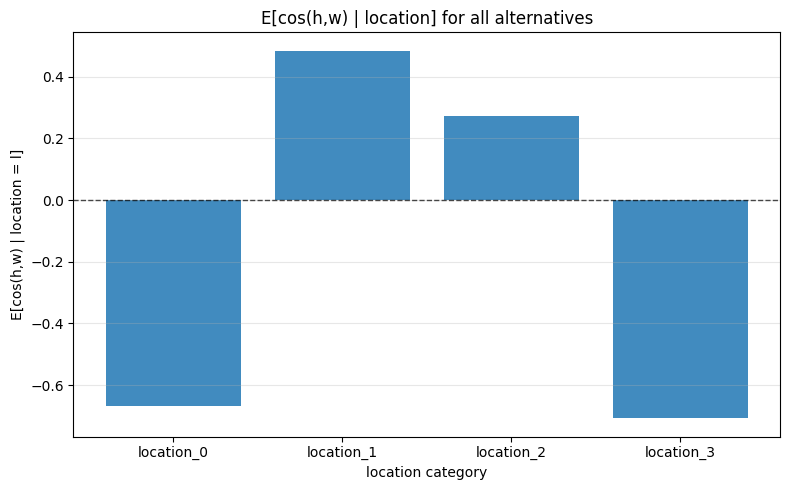

In [11]:
cos_loc_all_df, cos_loc_all_summary = compute_cos_hw_by_location(
    df=df,
    model=model,
    scaler=scaler,
    device=device,
    feat_names=feat_names,
    prefixes=("x1", "x2", "x3", "x4"),
    participant=None,
)

display(cos_loc_all_summary)

plot_df_all = plot_E_cos_hw_by_location(
    cos_loc_all_summary,
    title="E[cos(h,w) | location] for all alternatives"
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


@torch.no_grad()
def build_w_df(
    df: pd.DataFrame,
    model,
    scaler,
    device,
    *,
    take_candidate: str = "x1",
    batch_size: int = 1024,
):
    """
    Строит DataFrame с векторами w для каждой строки df.

    Использует model.encode_hw(x), который возвращает h, w, s.
    """

    if not hasattr(model, "encode_hw"):
        raise AttributeError("У модели должен быть метод encode_hw(x).")

    model.eval()

    cols_take = [f"{take_candidate}_{f}" for f in feat_names]
    missing = [c for c in cols_take if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    X = df[cols_take].to_numpy(dtype=np.float32)
    X_scaled = scaler.transform(X).astype(np.float32)

    all_w = []

    for start in range(0, len(X_scaled), batch_size):
        xb = torch.from_numpy(X_scaled[start:start + batch_size]).to(device)

        h, w, s = model.encode_hw(xb)

        all_w.append(w.detach().cpu().numpy())

    W = np.vstack(all_w)

    w_df = pd.DataFrame(W, columns=[f"w_{i}" for i in range(W.shape[1])])

    # мета-информация
    w_df["row_id"] = np.arange(len(df))
    w_df["linspace_session_id"] = df[f"{take_candidate}_linspace_session_id"].to_numpy()
    w_df["linspace_within_session"] = df[f"{take_candidate}_linspace_within_session"].to_numpy()

    # participant
    p_cols = [
        f"{take_candidate}_participant_J",
        f"{take_candidate}_participant_F",
        f"{take_candidate}_participant_Y",
    ]
    missing_p = [c for c in p_cols if c not in df.columns]
    if missing_p:
        raise ValueError(f"Missing participant columns: {missing_p}")

    p_mat = df[p_cols].to_numpy(dtype=np.float32)
    p_idx = p_mat.argmax(axis=1)
    p_names = np.array(["J", "F", "Y"], dtype=object)

    w_df["participant"] = p_names[p_idx]

    return w_df

def compute_adjacent_w_angles_global_time(
    w_df: pd.DataFrame,
    *,
    participant: str | None = None,
):
    """
    Строит единую временную ось:
      linspace_session_id -> linspace_within_session

    Затем считает углы между соседними w на этой оси.
    """

    df = w_df.copy()

    if participant is not None:
        if "participant" not in df.columns:
            raise ValueError("В w_df нет столбца 'participant'")
        df = df[df["participant"] == participant].copy()

    if len(df) < 2:
        raise ValueError("Недостаточно строк после фильтрации.")

    w_cols = [c for c in df.columns if c.startswith("w_")]
    if len(w_cols) == 0:
        raise ValueError("В w_df нет столбцов w_*")

    sort_cols = ["linspace_session_id", "linspace_within_session"]
    if "row_id" in df.columns:
        sort_cols.append("row_id")

    df = df.sort_values(sort_cols).reset_index(drop=True)

    # индекс в единой временной последовательности
    df["time_index"] = np.arange(len(df))

    # нормированная временная ось [0, 1]
    if len(df) == 1:
        df["time_through_sessions"] = 0.0
    else:
        df["time_through_sessions"] = df["time_index"] / (len(df) - 1)

    W = df[w_cols].to_numpy(dtype=np.float64)

    rows = []

    for i in range(len(df) - 1):
        w_left = W[i]
        w_right = W[i + 1]

        n_left = np.linalg.norm(w_left)
        n_right = np.linalg.norm(w_right)

        if n_left < 1e-12 or n_right < 1e-12:
            cos_val = np.nan
            angle_deg = np.nan
        else:
            cos_val = np.dot(w_left, w_right) / (n_left * n_right)
            cos_val = np.clip(cos_val, -1.0, 1.0)
            angle_deg = np.degrees(np.arccos(cos_val))

        rows.append({
            "left_time_index": i,
            "right_time_index": i + 1,
            "time_through_sessions": 0.5 * (
                df.loc[i, "time_through_sessions"] +
                df.loc[i + 1, "time_through_sessions"]
            ),
            "left_session_id": df.loc[i, "linspace_session_id"],
            "right_session_id": df.loc[i + 1, "linspace_session_id"],
            "left_within_session": df.loc[i, "linspace_within_session"],
            "right_within_session": df.loc[i + 1, "linspace_within_session"],
            "same_session": df.loc[i, "linspace_session_id"] == df.loc[i + 1, "linspace_session_id"],
            "cos_adjacent": cos_val,
            "angle_deg_adjacent": angle_deg,
        })

    angles_df = pd.DataFrame(rows)

    return df, angles_df


def plot_adjacent_w_angles_global_time(
    angles_df: pd.DataFrame,
    *,
    show_session_boundaries: bool = True,
    title: str | None = None,
):
    """
    Рисует угол между соседними w по единой временной оси.
    """

    if len(angles_df) == 0:
        raise ValueError("angles_df пустой.")

    plt.figure(figsize=(11, 5))

    plt.plot(
        angles_df["time_through_sessions"],
        angles_df["angle_deg_adjacent"],
        marker="o",
        linewidth=1.5,
        markersize=3,
    )

    if show_session_boundaries:
        boundaries = angles_df[~angles_df["same_session"]]
        for x in boundaries["time_through_sessions"]:
            plt.axvline(x=x, linestyle="--", alpha=0.25)

    plt.xlabel("time through sessions")
    plt.ylabel("angle between adjacent w, deg")
    plt.title(title or "Adjacent changes of w through sessions")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
w_df = build_w_df(
    df=df,
    model=model,
    scaler=scaler,
    device=device,
    take_candidate="x1",
)

w_ordered_df, angles_global_df = compute_adjacent_w_angles_global_time(
    w_df=w_df,
    participant="Y",   # "J", "F", "Y" или None
)

#display(w_ordered_df.head())
#display(angles_global_df.head())

plot_adjacent_w_angles_global_time(
    angles_df=angles_global_df,
    title="Adjacent angles of w through sessions, participant Y",
)

In [ ]:
def plot_session_boundary_w_angles(
    angles_df: pd.DataFrame,
    *,
    title: str | None = None,
):
    """
    Рисует только углы между соседними w на стыках сессий.
    То есть переходы, где left_session_id != right_session_id.
    """

    boundary_df = angles_df[~angles_df["same_session"]].copy()

    if len(boundary_df) == 0:
        raise ValueError("Нет переходов между сессиями: все соседние точки внутри одной session_id.")

    plt.figure(figsize=(10, 5))

    plt.scatter(
        boundary_df["time_through_sessions"],
        boundary_df["angle_deg_adjacent"],
        s=45,
        alpha=0.85,
    )

    plt.plot(
        boundary_df["time_through_sessions"],
        boundary_df["angle_deg_adjacent"],
        alpha=0.45,
        linewidth=1,
    )

    plt.xlabel("time through sessions")
    plt.ylabel("angle between adjacent w at session boundary, deg")
    plt.title(title or "Angles between w vectors at session boundaries")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return boundary_df

In [ ]:
boundary_angles_df = plot_session_boundary_w_angles(
    angles_global_df,
    title="Session-boundary changes of w, participant Y",
)

#display(boundary_angles_df)

In [ ]:
@torch.no_grad()
def build_correct_target_effect_over_time(
    df: pd.DataFrame,
    model,
    scaler,
    device,
    *,
    feat_names,
    take_candidate: str = "x1",
    participant: str | None = None,
    batch_size: int = 1024,
):
    """
    Для каждой строки строит counterfactual:
      correct_target = 0
      correct_target = 1

    Считает:
      - delta_score = s(1) - s(0)
      - delta_cos_hw = cos(h1,w1) - cos(h0,w0)
      - angle_h_0_1 = угол между h при correct_target=0 и correct_target=1
      - angle_w_0_1 = угол между w при correct_target=0 и correct_target=1

    Затем добавляет нормированную ось time_through_sessions,
    построенную по linspace_session_id и linspace_within_session.
    """

    if not hasattr(model, "encode_hw"):
        raise AttributeError("У модели должен быть метод encode_hw(x).")

    df_work = df.copy()

    if participant is not None:
        if participant not in ("J", "F", "Y"):
            raise ValueError("participant must be one of: 'J', 'F', 'Y', or None")

        p_col = f"{take_candidate}_participant_{participant}"
        if p_col not in df_work.columns:
            raise ValueError(f"Нет столбца {p_col}")

        df_work = df_work[df_work[p_col] == 1].copy()

    if len(df_work) == 0:
        raise ValueError("После фильтрации не осталось строк.")

    sort_cols = [
        f"{take_candidate}_linspace_session_id",
        f"{take_candidate}_linspace_within_session",
    ]
    if "row_id" in df_work.columns:
        sort_cols.append("row_id")

    df_work = df_work.sort_values(sort_cols).reset_index(drop=True)

    df_work["time_index"] = np.arange(len(df_work))
    df_work["time_through_sessions"] = (
        df_work["time_index"] / max(len(df_work) - 1, 1)
    )

    # две копии: correct_target=0 и correct_target=1
    df0 = df_work.copy()
    df1 = df_work.copy()

    target_col = f"{take_candidate}_correct_target"
    if target_col not in df_work.columns:
        raise ValueError(f"Нет столбца {target_col}")

    df0[target_col] = 0.0
    df1[target_col] = 1.0

    cols_take = [f"{take_candidate}_{f}" for f in feat_names]

    X0 = df0[cols_take].to_numpy(dtype=np.float32)
    X1 = df1[cols_take].to_numpy(dtype=np.float32)

    X0 = scaler.transform(X0).astype(np.float32)
    X1 = scaler.transform(X1).astype(np.float32)

    H0, W0, S0 = [], [], []
    H1, W1, S1 = [], [], []

    model.eval()

    for start in range(0, len(df_work), batch_size):
        sl = slice(start, start + batch_size)

        x0 = torch.from_numpy(X0[sl]).to(device)
        x1 = torch.from_numpy(X1[sl]).to(device)

        h0, w0, s0 = model.encode_hw(x0)
        h1, w1, s1 = model.encode_hw(x1)

        H0.append(h0.detach().cpu().numpy())
        W0.append(w0.detach().cpu().numpy())
        S0.append(s0.detach().cpu().numpy())

        H1.append(h1.detach().cpu().numpy())
        W1.append(w1.detach().cpu().numpy())
        S1.append(s1.detach().cpu().numpy())

    H0 = np.vstack(H0)
    W0 = np.vstack(W0)
    S0 = np.concatenate(S0)

    H1 = np.vstack(H1)
    W1 = np.vstack(W1)
    S1 = np.concatenate(S1)

    def cosine_rows(A, B):
        denom = np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1)
        cos = np.sum(A * B, axis=1) / np.maximum(denom, 1e-12)
        return np.clip(cos, -1.0, 1.0)

    cos0 = cosine_rows(H0, W0)
    cos1 = cosine_rows(H1, W1)

    cos_h01 = cosine_rows(H0, H1)
    angle_h01 = np.degrees(np.arccos(cos_h01))

    cos_w01 = cosine_rows(W0, W1)
    angle_w01 = np.degrees(np.arccos(cos_w01))

    out = pd.DataFrame({
        "time_index": df_work["time_index"].to_numpy(),
        "time_through_sessions": df_work["time_through_sessions"].to_numpy(),
        "linspace_session_id": df_work[f"{take_candidate}_linspace_session_id"].to_numpy(),
        "linspace_within_session": df_work[f"{take_candidate}_linspace_within_session"].to_numpy(),
        "original_correct_target": df_work[target_col].to_numpy(),
        "s_correct_0": S0,
        "s_correct_1": S1,
        "delta_score_correct_1_minus_0": S1 - S0,
        "cos_hw_correct_0": cos0,
        "cos_hw_correct_1": cos1,
        "delta_cos_hw_correct_1_minus_0": cos1 - cos0,
        "angle_h_correct_0_1": angle_h01,
        "angle_w_correct_0_1": angle_w01,
    })

    if "participant" in df_work.columns:
        out["participant"] = df_work["participant"].to_numpy()
    elif participant is not None:
        out["participant"] = participant

    return out


def add_rolling_columns(
    effect_df: pd.DataFrame,
    *,
    window: int = 51,
):
    """
    Добавляет скользящие средние для ключевых величин.
    window лучше брать нечётным.
    """
    df = effect_df.sort_values("time_through_sessions").reset_index(drop=True).copy()

    cols = [
        "delta_score_correct_1_minus_0",
        "delta_cos_hw_correct_1_minus_0",
        "angle_h_correct_0_1",
        "angle_w_correct_0_1",
        "original_correct_target",
    ]

    for c in cols:
        df[f"{c}_roll"] = (
            df[c]
            .rolling(window=window, center=True, min_periods=max(5, window // 5))
            .mean()
        )

    return df


def plot_correct_target_effect_over_time(
    effect_df: pd.DataFrame,
    *,
    window: int = 51,
    title_prefix: str = "",
):
    df = add_rolling_columns(effect_df, window=window)

    fig, axs = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

    x = df["time_through_sessions"]

    axs[0].scatter(
        x,
        df["delta_score_correct_1_minus_0"],
        s=8,
        alpha=0.20,
    )

    axs[0].plot(
        x,
        df["delta_score_correct_1_minus_0_roll"],
        linewidth=2.5,
    )

    axs[0].axhline(0, linestyle="--", linewidth=1)
    axs[0].set_ylabel("Δ score")
    axs[0].set_title(f"{title_prefix}Effect of correct_target over time")
    axs[0].grid(True, alpha=0.3)

    axs[1].scatter(
        x,
        df["delta_cos_hw_correct_1_minus_0"],
        s=8,
        alpha=0.20,
    )

    axs[1].plot(
        x,
        df["delta_cos_hw_correct_1_minus_0_roll"],
        linewidth=2.5,
    )

    axs[1].axhline(0, linestyle="--", linewidth=1)
    axs[1].set_ylabel("Δ cos(h,w)")
    axs[1].grid(True, alpha=0.3)

    axs[2].scatter(
        x,
        df["angle_h_correct_0_1"],
        s=8,
        alpha=0.20,
    )

    axs[2].plot(
        x,
        df["angle_h_correct_0_1_roll"],
        linewidth=2.5,
    )

    axs[2].set_ylabel("angle(h0,h1), deg")
    axs[2].grid(True, alpha=0.3)

    axs[3].plot(
        x,
        df["original_correct_target_roll"],
        linewidth=2.5,
    )

    axs[3].set_ylabel("rolling mean\ncorrect_target")
    axs[3].set_xlabel("time through sessions")
    axs[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return df

In [ ]:
effect_ = build_correct_target_effect_over_time(
    df=df,          # или df_trva
    model=model,
    scaler=scaler,
    device=device,
    feat_names=feat_names,
    participant="F",     # "J", "F", "Y" или None
    take_candidate="x1",
)

effect_roll = plot_correct_target_effect_over_time(
    effect_,
    window=51,
    title_prefix="Participant F: ",
)

In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def build_score_location_time_df(
    df: pd.DataFrame,
    model,
    scaler,
    device,
    *,
    feat_names,
    take_candidate: str = "x1",
    participant: str | None = None,
    batch_size: int = 1024,
):
    """
    Строит DataFrame:
      - time_through_sessions
      - location
      - score s
      - participant
    """

    df_work = df.copy()

    if participant is not None:
        if participant not in ("J", "F", "Y"):
            raise ValueError("participant must be 'J', 'F', 'Y' or None")

        p_col = f"{take_candidate}_participant_{participant}"
        df_work = df_work[df_work[p_col] == 1].copy()

    if len(df_work) == 0:
        raise ValueError("После фильтрации не осталось строк.")

    df_work = df_work.sort_values([
        f"{take_candidate}_linspace_session_id",
        f"{take_candidate}_linspace_within_session",
    ]).reset_index(drop=True)

    df_work["time_index"] = np.arange(len(df_work))
    df_work["time_through_sessions"] = (
        df_work["time_index"] / max(len(df_work) - 1, 1)
    )

    loc_cols = [f"{take_candidate}_location_{i}" for i in range(4)]
    df_work["location"] = df_work[loc_cols].to_numpy(dtype=np.float32).argmax(axis=1)

    cols_take = [f"{take_candidate}_{f}" for f in feat_names]
    X = df_work[cols_take].to_numpy(dtype=np.float32)
    X_scaled = scaler.transform(X).astype(np.float32)

    scores = []

    model.eval()

    for start in range(0, len(X_scaled), batch_size):
        xb = torch.from_numpy(X_scaled[start:start + batch_size]).to(device)
        _, _, s = model.encode_hw(xb)
        scores.append(s.detach().cpu().numpy())

    scores = np.concatenate(scores)

    out = pd.DataFrame({
        "time_through_sessions": df_work["time_through_sessions"].to_numpy(),
        "linspace_session_id": df_work[f"{take_candidate}_linspace_session_id"].to_numpy(),
        "linspace_within_session": df_work[f"{take_candidate}_linspace_within_session"].to_numpy(),
        "location": df_work["location"].to_numpy(),
        "score_s": scores,
    })

    if participant is not None:
        out["participant"] = participant

    return out


def summarize_score_by_location_time_bins(
    score_df: pd.DataFrame,
    *,
    n_bins: int = 20,
):
    """
    Разбивает time_through_sessions на интервалы
    и считает E[s | location, time_bin].
    """

    df = score_df.copy()

    df["time_bin"] = pd.cut(
        df["time_through_sessions"],
        bins=np.linspace(0, 1, n_bins + 1),
        include_lowest=True,
        labels=False,
    )

    summary = (
        df.groupby(["time_bin", "location"])["score_s"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    summary["time_mid"] = (summary["time_bin"] + 0.5) / n_bins
    summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"].clip(lower=1))

    return summary


def plot_score_by_location_over_time(
    summary_df: pd.DataFrame,
    *,
    title: str = "E[s | location] over time",
    show_ci: bool = True,
):
    colors = {
        0: "tab:blue",
        1: "tab:orange",
        2: "tab:green",
        3: "tab:red",
    }

    plt.figure(figsize=(11, 5))

    for loc in sorted(summary_df["location"].unique()):
        sub = summary_df[summary_df["location"] == loc].sort_values("time_mid")

        x = sub["time_mid"].to_numpy()
        y = sub["mean"].to_numpy()

        plt.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            color=colors.get(loc, None),
            label=f"location {loc}",
        )

        if show_ci:
            ci = sub["ci95"].to_numpy()
            plt.fill_between(
                x,
                y - ci,
                y + ci,
                color=colors.get(loc, None),
                alpha=0.18,
            )

    plt.axhline(0, linestyle="--", color="black", linewidth=1, alpha=0.7)

    plt.xlabel("time through sessions")
    plt.ylabel("mean score s")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
score_loc_F = build_score_location_time_df(
    df=df,          # или df_trva
    model=model,
    scaler=scaler,
    device=device,
    feat_names=feat_names,
    participant="J",     # "J", "F", "Y" или None
    take_candidate="x1",
)

summary_F = summarize_score_by_location_time_bins(
    score_loc_F,
    n_bins=20,
)
summary_F = summary_F[summary_F["count"] >= 3]

plot_score_by_location_over_time(
    summary_F,
    title="E[s | location] over time, participant J",
)

In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def build_model_vs_choice_gap_with_location(
    df: pd.DataFrame,
    model,
    scaler,
    device,
    *,
    feat_names,
    participant: str | None = None,
    batch_size: int = 1024,
):
    """
    Считает для каждой строки:
      s_x1      = score реально выбранного стимула x1
      s_best    = max score среди x1, x2, x3, x4
      gap       = s_best - s_x1

    Также добавляет:
      - model_choice_idx: какой кандидат выбран моделью
      - model_correct: совпал ли выбор модели с x1
      - actual_location: location реально выбранного x1
      - time_through_sessions
    """

    df_work = df.copy()

    if participant is not None:
        if participant not in ("J", "F", "Y"):
            raise ValueError("participant must be one of: 'J', 'F', 'Y', or None")

        p_col = f"x1_participant_{participant}"
        if p_col not in df_work.columns:
            raise ValueError(f"Нет столбца {p_col}")

        df_work = df_work[df_work[p_col] == 1].copy()

    if len(df_work) == 0:
        raise ValueError("После фильтрации не осталось строк.")

    # единая временная ось
    df_work = df_work.sort_values([
        "x1_linspace_session_id",
        "x1_linspace_within_session",
    ]).reset_index(drop=True)

    df_work["time_index"] = np.arange(len(df_work))
    df_work["time_through_sessions"] = (
        df_work["time_index"] / max(len(df_work) - 1, 1)
    )

    model.eval()

    scores_all = []

    for pref in ["x1", "x2", "x3", "x4"]:
        cols = [f"{pref}_{f}" for f in feat_names]
        missing = [c for c in cols if c not in df_work.columns]
        if missing:
            raise ValueError(f"Missing columns for {pref}: {missing}")

        X = df_work[cols].to_numpy(dtype=np.float32)
        X_scaled = scaler.transform(X).astype(np.float32)

        s_parts = []

        for start in range(0, len(X_scaled), batch_size):
            xb = torch.from_numpy(X_scaled[start:start + batch_size]).to(device)

            if hasattr(model, "encode_hw"):
                _, _, s = model.encode_hw(xb)
            else:
                s = model(xb)

            s_parts.append(s.detach().cpu().numpy())

        scores_all.append(np.concatenate(s_parts))

    scores_all = np.stack(scores_all, axis=1)  # (N, 4)

    model_choice_idx = scores_all.argmax(axis=1)
    s_x1 = scores_all[:, 0]
    s_best = scores_all[np.arange(len(df_work)), model_choice_idx]

    gap = s_best - s_x1

    # фактический location выбранного x1
    loc_cols = [f"x1_location_{i}" for i in range(4)]
    missing_loc = [c for c in loc_cols if c not in df_work.columns]
    if missing_loc:
        raise ValueError(f"Missing location columns: {missing_loc}")

    actual_location = df_work[loc_cols].to_numpy(dtype=np.float32).argmax(axis=1)

    out = pd.DataFrame({
        "time_through_sessions": df_work["time_through_sessions"].to_numpy(),
        "time_index": df_work["time_index"].to_numpy(),
        "linspace_session_id": df_work["x1_linspace_session_id"].to_numpy(),
        "linspace_within_session": df_work["x1_linspace_within_session"].to_numpy(),
        "actual_location": actual_location,
        "s_x1": s_x1,
        "s_best": s_best,
        "gap_s_best_minus_x1": gap,
        "model_choice_idx": model_choice_idx,
        "model_correct": model_choice_idx == 0,
    })

    if participant is not None:
        out["participant"] = participant

    for j in range(4):
        out[f"s_x{j+1}"] = scores_all[:, j]

    return out


def plot_model_vs_choice_gap_by_location(
    gap_df: pd.DataFrame,
    *,
    window: int = 51,
    title: str | None = None,
):
    """
    Рисует:
      - точки gap = s_best - s_x1, раскрашенные по actual_location
      - общую сглаженную линию gap
    """

    colors = {
        0: "tab:blue",
        1: "tab:orange",
        2: "tab:green",
        3: "tab:red",
    }

    df = gap_df.sort_values("time_through_sessions").reset_index(drop=True).copy()

    plt.figure(figsize=(12, 5))

    for loc in sorted(df["actual_location"].unique()):
        sub = df[df["actual_location"] == loc]

        plt.scatter(
            sub["time_through_sessions"],
            sub["gap_s_best_minus_x1"],
            s=12,
            alpha=0.35,
            color=colors.get(loc, None),
            label=f"actual location {loc}",
        )

    # скользящее среднее общей ошибки модели
    df["gap_roll"] = (
        df["gap_s_best_minus_x1"]
        .rolling(window=window, center=True, min_periods=max(5, window // 5))
        .mean()
    )

    plt.plot(
        df["time_through_sessions"],
        df["gap_roll"],
        color="black",
        linewidth=2.5,
        label=f"rolling mean, window={window}",
    )

    plt.axhline(0, linestyle="--", color="black", linewidth=1, alpha=0.7)

    plt.xlabel("time through sessions")
    plt.ylabel("s(model best) - s(chosen x1)")
    plt.title(title or "Model-vs-choice score gap over time")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_model_accuracy_over_time(
    gap_df: pd.DataFrame,
    *,
    window: int = 51,
    title: str | None = None,
):
    """
    Дополнительный график:
    скользящая доля совпадения выбора модели с x1.
    """

    df = gap_df.sort_values("time_through_sessions").reset_index(drop=True).copy()

    df["model_correct_roll"] = (
        df["model_correct"]
        .astype(float)
        .rolling(window=window, center=True, min_periods=max(5, window // 5))
        .mean()
    )

    plt.figure(figsize=(12, 4))

    plt.plot(
        df["time_through_sessions"],
        df["model_correct_roll"],
        linewidth=2.5,
    )

    plt.xlabel("time through sessions")
    plt.ylabel("rolling model accuracy")
    plt.title(title or "Model agreement with chosen x1 over time")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
gap_F = build_model_vs_choice_gap_with_location(
    df=df,
    model=model,
    scaler=scaler,
    device=device,
    feat_names=feat_names,
    participant="J",   # "J", "F", "Y" или None
)


plot_model_vs_choice_gap_by_location(
    gap_F,
    window=51,
    title="Model-vs-choice score gap over time, participant J",
)

plot_model_accuracy_over_time(
    gap_F,
    window=51,
    title="Model agreement with chosen x1 over time, participant J",
)